<a href="https://colab.research.google.com/github/api-sage/systems_stochastic_processes/blob/main/jezero_crater_clustering/jezero_crater_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I import the numerical, tabular, and plotting tools I use throughout this notebook, then add the distribution and clustering tools needed for the robust mixture model and its PCA view.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

### Exponential Distribution and Network Traffic
#### Simulation of 1000 Interarrival Times

I answer the simulation portion by drawing 1,000 exponential interarrival times with a four-millisecond mean and plotting their distribution.

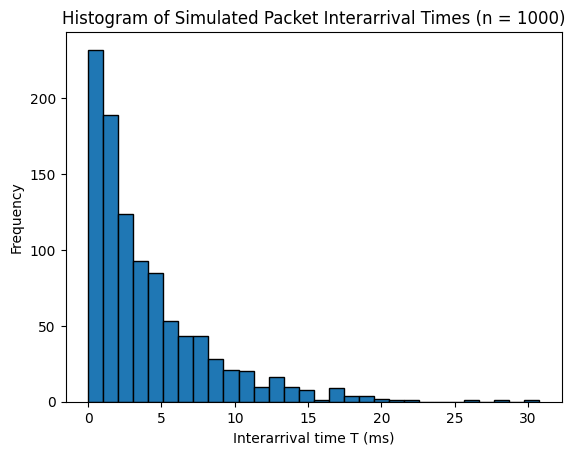

In [2]:
np.random.seed(2025)
lam = 0.25
T_samples = np.random.exponential(scale=1/lam, size=1000)
plt.figure()
plt.hist(T_samples, bins=30, edgecolor='black')
plt.xlabel("Interarrival time T (ms)")
plt.ylabel("Frequency")
plt.title("Histogram of Simulated Packet Interarrival Times (n = 1000)")
plt.savefig("interarrival_histogram.pdf")
plt.show()

### Normal Distribution and Sensor Calibration
#### Simulation of 10,000 Sensor Outputs

I answer the simulation portion by drawing 10,000 sensor voltages from the specified normal distribution, visualizing them, and estimating their fifth percentile.

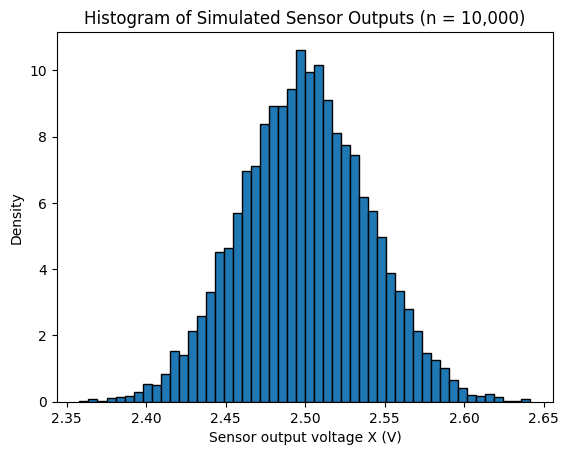

Empirical 5th percentile: 2.434249091435471


In [3]:
np.random.seed(2025)
mu, sigma = 2.50, 0.04
X_samples = np.random.normal(loc=mu, scale=sigma, size=10000)
plt.figure()
plt.hist(X_samples, bins=50, edgecolor='black', density=True)
plt.xlabel("Sensor output voltage X (V)")
plt.ylabel("Density")
plt.title("Histogram of Simulated Sensor Outputs (n = 10,000)")
plt.savefig("sensor_output_histogram.pdf")
plt.show()
empirical_5th_percentile = np.percentile(X_samples, 5)
print("Empirical 5th percentile:", empirical_5th_percentile)

## Jezero Crater Rock Chemistry: Data Inspection and Bias Correction

I begin building a robust clustering pipeline for five chemical measurements collected from rock samples in Jezero crater. I simulate samples representing Igneous, Sedimentary, and Altered by Water formations, with timestamps recording local Mars time. I include a conditional instrument error that adds 3.0 concentration units to the silica measurement (feature 0) between 18:00 and 06:00; this deliberately clear offset lets me inspect and correct the effect. I also include approximately 5% diffuse ChemCam misfire readings as labeled noise. I retain those samples here, since outlier handling and clustering are outside this initial data-inspection stage.

## Data Generation and Inspection

I generate balanced samples from three distinct five-dimensional Gaussian distributions, attach independent uniformly distributed local-time timestamps, and add diffuse noise samples to represent occasional laser misfires. I treat the feature values as synthetic concentration-like measurements and consistently represent silica with column 0. I use a fixed seed so the data and visual checks can be reproduced.

In [4]:
FEATURE_NAMES = ["Silica", "Iron", "Magnesium", "Calcium", "Sulfur"]
ROCK_TYPES = ["Igneous", "Sedimentary", "Altered by Water"]
SILICA_INDEX = 0
NIGHT_BIAS = 3.0


def generate_mars_data(seed=2025):
    """Generate synthetic rock chemistry, local-time timestamps, and labels."""
    rng = np.random.RandomState(seed)
    means = [
        [52.0, 18.0, 14.0, 8.0, 2.0],
        [43.0, 9.0, 8.0, 17.0, 5.0],
        [48.0, 13.0, 19.0, 11.0, 8.0],
    ]
    standard_deviations = [
        [4.0, 3.0, 2.5, 2.0, 1.0],
        [3.5, 2.0, 2.0, 3.0, 1.5],
        [4.5, 2.5, 3.0, 2.5, 2.0],
    ]
    sample_counts = [95, 95, 95]

    feature_groups = []
    label_groups = []
    for rock_type, mean, standard_deviation, sample_count in zip(
        ROCK_TYPES, means, standard_deviations, sample_counts
    ):
        covariance = np.diag(np.square(standard_deviation))
        samples = rng.multivariate_normal(mean, covariance, size=sample_count)
        feature_groups.append(samples)
        label_groups.extend([rock_type] * sample_count)

    noise_count = 15
    noise_samples = rng.uniform(
        low=[5.0, -5.0, -5.0, -5.0, -2.0],
        high=[80.0, 45.0, 40.0, 35.0, 22.0],
        size=(noise_count, len(FEATURE_NAMES)),
    )
    feature_groups.append(noise_samples)
    label_groups.extend(["ChemCam noise"] * noise_count)

    features = np.vstack(feature_groups)
    labels = np.asarray(label_groups, dtype=object)
    timestamps = rng.uniform(0.0, 24.0, size=len(features))

    night_mask = (timestamps >= 18.0) | (timestamps < 6.0)
    features[night_mask, SILICA_INDEX] += NIGHT_BIAS

    permutation = rng.permutation(len(features))
    return features[permutation], timestamps[permutation], labels[permutation]


X_raw, timestamps, true_labels = generate_mars_data()
night_mask = (timestamps >= 18.0) | (timestamps < 6.0)
day_mask = ~night_mask

print(f"Samples: {len(X_raw)}")
print(pd.Series(true_labels).value_counts().to_string())
print(f"Day samples: {day_mask.sum()}, night samples: {night_mask.sum()}")

Samples: 300
Igneous             95
Altered by Water    95
Sedimentary         95
ChemCam noise       15
Day samples: 148, night samples: 152


I inspect the raw feature relationships and compare silica readings by timestamp window. I use the pairwise view to see the simulated formation groups alongside the deliberately diffuse noise, and to check that the silica distributions show the instrument's positive night-time shift. I leave noise samples visible because I have not filtered or reassigned any observations.

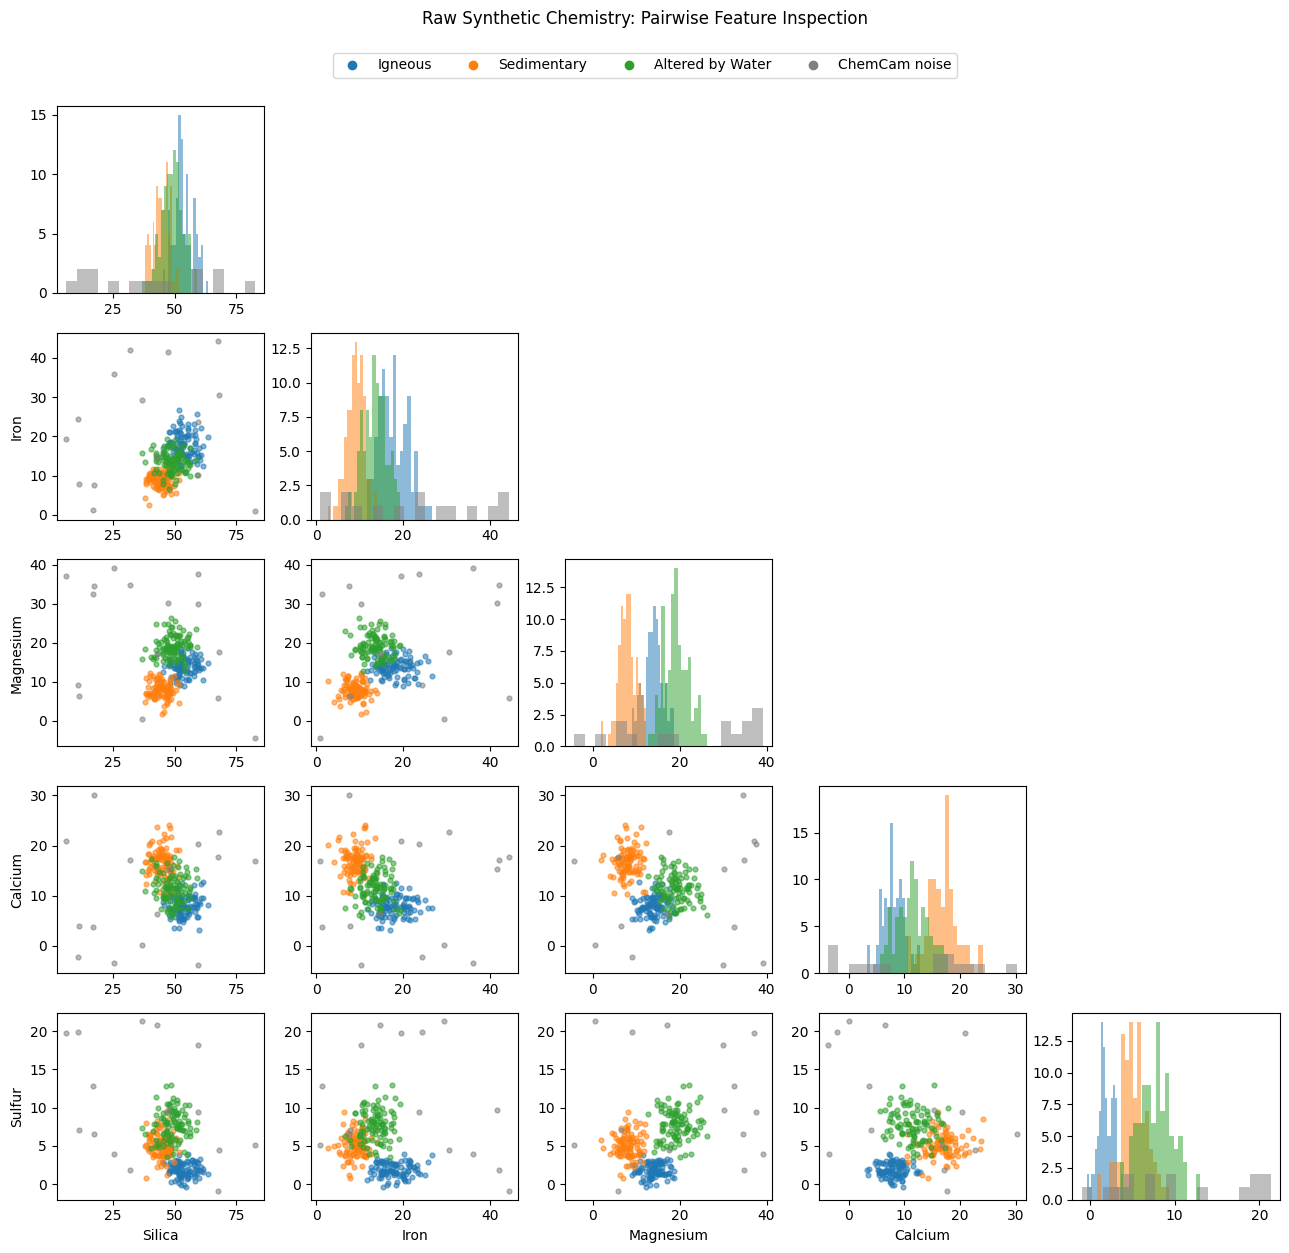

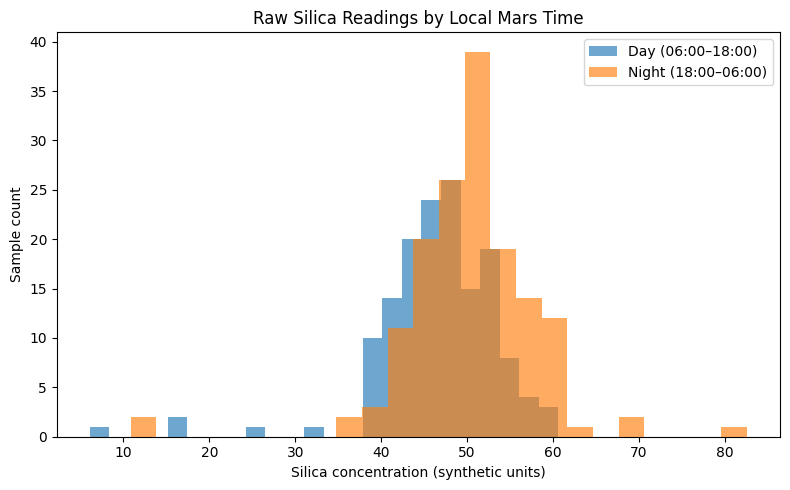

Raw mean silica — day: 46.54; night: 50.52


In [5]:
colors = {
    "Igneous": "tab:blue",
    "Sedimentary": "tab:orange",
    "Altered by Water": "tab:green",
    "ChemCam noise": "tab:gray",
}

fig, axes = plt.subplots(len(FEATURE_NAMES), len(FEATURE_NAMES), figsize=(13, 12))
for row in range(len(FEATURE_NAMES)):
    for column in range(len(FEATURE_NAMES)):
        ax = axes[row, column]
        if row == column:
            for label in colors:
                values = X_raw[true_labels == label, row]
                ax.hist(values, bins=18, alpha=0.5, color=colors[label], label=label)
        elif row > column:
            for label in colors:
                mask = true_labels == label
                ax.scatter(
                    X_raw[mask, column], X_raw[mask, row],
                    s=12, alpha=0.55, color=colors[label], label=label
                )
        else:
            ax.set_visible(False)
        if row == len(FEATURE_NAMES) - 1 and column < row:
            ax.set_xlabel(FEATURE_NAMES[column])
        if column == 0 and row > 0:
            ax.set_ylabel(FEATURE_NAMES[row])

handles = [
    plt.Line2D([], [], marker="o", linestyle="", color=colors[label], label=label)
    for label in colors
]
fig.legend(handles=handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.01))
fig.suptitle("Raw Synthetic Chemistry: Pairwise Feature Inspection", y=1.04)
fig.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(X_raw[day_mask, SILICA_INDEX], bins=24, alpha=0.65, label="Day (06:00–18:00)")
plt.hist(X_raw[night_mask, SILICA_INDEX], bins=24, alpha=0.65, label="Night (18:00–06:00)")
plt.xlabel("Silica concentration (synthetic units)")
plt.ylabel("Sample count")
plt.title("Raw Silica Readings by Local Mars Time")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Raw mean silica — day: {X_raw[day_mask, SILICA_INDEX].mean():.2f}; "
      f"night: {X_raw[night_mask, SILICA_INDEX].mean():.2f}")

I see the night-time silica readings shifted higher than daytime readings, as expected from the simulated conditional bias. I also see in the pairwise plots that observations include both the three underlying formations and a broader set of noise readings. I interpret the time-group comparison as informative when day and night samples have similar formation composition; in this simulation, I assign timestamps independently of formation labels.

## Correcting Systematic Bias in Silica Readings

I identify night samples directly from their local-time timestamps, including the interval crossing midnight. I estimate the additive offset as the observed mean silica difference between night and day, then subtract that estimate from every night-time silica reading. I consider this data-driven estimate appropriate here because I assigned timestamps independently of rock type, so both time groups have comparable expected formation mixtures. I do not need to treat the injected offset as known during correction. I retain diffuse misfire readings, which can influence my mean estimate.

In [6]:
estimated_bias = (
    X_raw[night_mask, SILICA_INDEX].mean()
    - X_raw[day_mask, SILICA_INDEX].mean()
)
X_corrected = X_raw.copy()
X_corrected[night_mask, SILICA_INDEX] -= estimated_bias

print(f"Estimated night-time silica offset: {estimated_bias:.2f} synthetic units")
print(f"Corrected mean silica — day: {X_corrected[day_mask, SILICA_INDEX].mean():.2f}; "
      f"night: {X_corrected[night_mask, SILICA_INDEX].mean():.2f}")

Estimated night-time silica offset: 3.98 synthetic units
Corrected mean silica — day: 46.54; night: 46.54


I compare the silica distributions before and after my estimated correction, then inspect corrected silica against iron to check that day and night observations now share a comparable relationship.

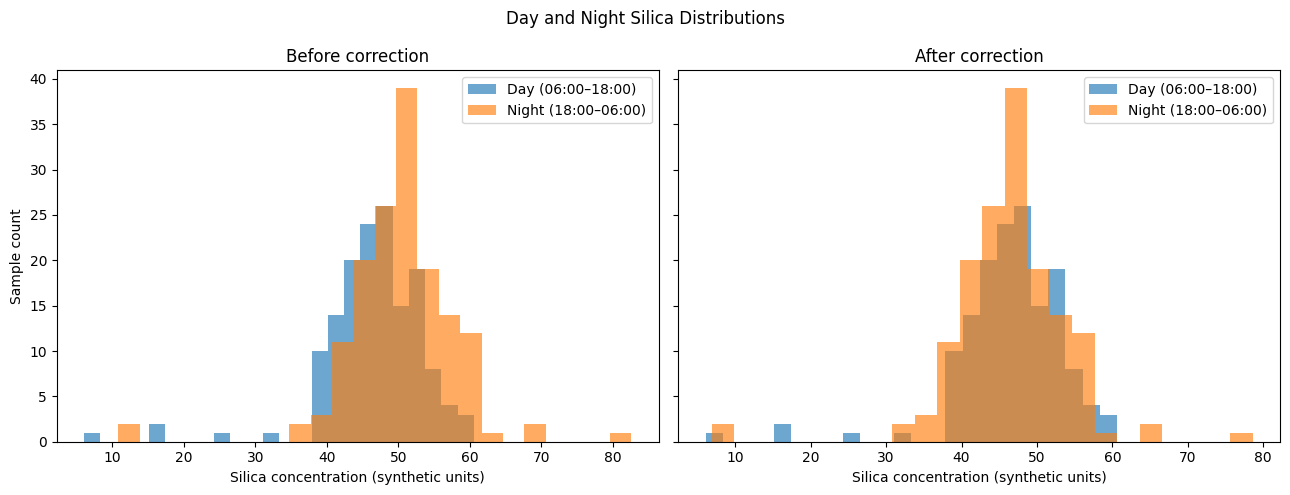

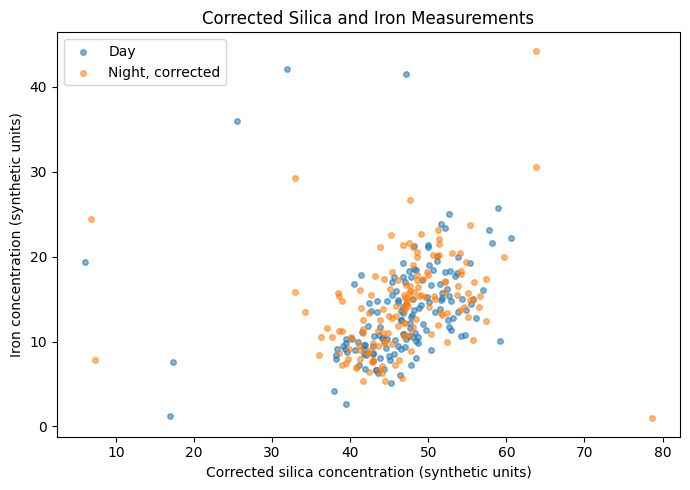

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, silica_values, title in [
    (axes[0], X_raw[:, SILICA_INDEX], "Before correction"),
    (axes[1], X_corrected[:, SILICA_INDEX], "After correction"),
]:
    ax.hist(silica_values[day_mask], bins=24, alpha=0.65, label="Day (06:00–18:00)")
    ax.hist(silica_values[night_mask], bins=24, alpha=0.65, label="Night (18:00–06:00)")
    ax.set_xlabel("Silica concentration (synthetic units)")
    ax.set_title(title)
    ax.legend()
axes[0].set_ylabel("Sample count")
fig.suptitle("Day and Night Silica Distributions")
fig.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(X_corrected[day_mask, SILICA_INDEX], X_corrected[day_mask, 1],
            s=16, alpha=0.55, label="Day", color="tab:blue")
plt.scatter(X_corrected[night_mask, SILICA_INDEX], X_corrected[night_mask, 1],
            s=16, alpha=0.55, label="Night, corrected", color="tab:orange")
plt.xlabel("Corrected silica concentration (synthetic units)")
plt.ylabel("Iron concentration (synthetic units)")
plt.title("Corrected Silica and Iron Measurements")
plt.legend()
plt.tight_layout()
plt.show()

After correction, I find that day and night mean silica readings align, and their distributions are much more comparable than before. I may still see local differences because a finite sample produces random variation, and the approximately 5% diffuse noise can affect my estimated means. My correction mitigates the time-based shift; it does not remove noise or guarantee that every individual measurement is accurate. I will address outlier handling and clustering model development in subsequent work.

## Robust Mixture Model: Assignment Step

I review and use the Assignment Step as given by Bayes' rule: for each corrected five-dimensional sample, I multiply each Gaussian density by its mixing weight and compare it with the weighted uniform outlier density. I normalize these four joint probabilities so every sample has responsibilities that sum to one. The uniform density is constant inside the five-dimensional bounding box of the corrected observations, whose volume I calculate from the observed coordinate ranges; this gives diffuse outliers a nonzero likelihood without fitting a shape to them.

In [ ]:
def e_step(X, means, covariances, mixing_weights, uniform_density):
    """Compute posterior responsibilities for three Gaussians and one uniform component."""
    X = np.asarray(X, dtype=float)
    responsibilities = np.empty((X.shape[0], 4), dtype=float)
    for component in range(3):
        responsibilities[:, component] = mixing_weights[component] * multivariate_normal.pdf(
            X, mean=means[component], cov=covariances[component], allow_singular=True
        )
    responsibilities[:, 3] = mixing_weights[3] * uniform_density
    row_totals = responsibilities.sum(axis=1, keepdims=True)
    return responsibilities / np.maximum(row_totals, np.finfo(float).tiny)

## Robust Mixture Model: Update Step

I update each Gaussian from its current responsibilities, connecting these parameters to the mean vector and covariance matrix I used to describe each formation in my earlier analysis. For component $k$, I let $N_k=\sum_i r_{ik}$, calculate its weighted mean as $\mu_k=\sum_i r_{ik}x_i/N_k$, and calculate its weighted covariance as $\Sigma_k=\sum_i r_{ik}(x_i-\mu_k)(x_i-\mu_k)^T/N_k$. I set each mixing weight, including the uniform component, to $N_k/n$; because the responsibilities sum to one per observation, these four weights sum to one. I add a small diagonal covariance floor for numerical stability.

In [ ]:
def m_step(X, responsibilities, regularization=1e-6):
    """Update Gaussian means/covariances and all four mixing weights."""
    X = np.asarray(X, dtype=float)
    effective_counts = responsibilities.sum(axis=0)
    mixing_weights = effective_counts / X.shape[0]
    means = np.empty((3, X.shape[1]), dtype=float)
    covariances = np.empty((3, X.shape[1], X.shape[1]), dtype=float)
    identity = np.eye(X.shape[1])
    for component in range(3):
        weights = responsibilities[:, component]
        means[component] = weights @ X / effective_counts[component]
        centered = X - means[component]
        covariances[component] = (centered.T * weights) @ centered / effective_counts[component]
        covariances[component] += regularization * identity
    return means, covariances, mixing_weights

## Iterative Robust Mixture Model

I combine the Assignment and Update Steps in an iterative fit method. I initialize the three Gaussian components with a reproducible K-means partition in standardized feature space, give the uniform component a 0.05 starting weight to reflect the simulated contamination rate, and divide the remaining weight equally among the Gaussians. At each iteration I record the total log-likelihood across all four components; this value must never decrease, so its non-decreasing behavior is an important sanity check that the EM updates are behaving as expected. I stop early when the change is below a small tolerance, while still allowing up to 40 iterations.

In [ ]:
class RobustMixtureModel:
    """Three Gaussian rock clusters plus a uniform component for outliers."""

    def __init__(self, regularization=1e-6, random_state=2025):
        self.regularization = regularization
        self.random_state = random_state

    def _log_likelihood(self, X):
        joint = np.empty((X.shape[0], 4), dtype=float)
        for component in range(3):
            joint[:, component] = self.mixing_weights_[component] * multivariate_normal.pdf(
                X, mean=self.means_[component], cov=self.covariances_[component],
                allow_singular=True
            )
        joint[:, 3] = self.mixing_weights_[3] * self.uniform_density_
        return np.log(np.maximum(joint.sum(axis=1), np.finfo(float).tiny)).sum()

    def fit(self, X, n_iter=40, tolerance=1e-6):
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or X.shape[1] != 5 or X.shape[0] < 4:
            raise ValueError("X must contain at least four samples with five features each")
        lower, upper = X.min(axis=0), X.max(axis=0)
        self.uniform_density_ = 1.0 / np.prod(upper - lower)
        feature_scale = X.std(axis=0)
        standardized = (X - X.mean(axis=0)) / np.where(feature_scale > 0, feature_scale, 1.0)
        initializer = KMeans(n_clusters=3, n_init=10, random_state=self.random_state)
        initial_labels = initializer.fit_predict(standardized)
        self.means_ = np.vstack([X[initial_labels == k].mean(axis=0) for k in range(3)])
        self.covariances_ = np.stack([
            np.cov(X[initial_labels == k], rowvar=False) + self.regularization * np.eye(X.shape[1])
            for k in range(3)
        ])
        self.mixing_weights_ = np.array([0.95 / 3, 0.95 / 3, 0.95 / 3, 0.05])
        responsibilities = e_step(
            X, self.means_, self.covariances_, self.mixing_weights_, self.uniform_density_
        )
        self.log_likelihood_trace_ = [self._log_likelihood(X)]
        print(f"Iteration 1: log-likelihood = {self.log_likelihood_trace_[-1]:.6f}")

        for iteration in range(2, n_iter + 1):
            previous_log_likelihood = self.log_likelihood_trace_[-1]
            self.means_, self.covariances_, self.mixing_weights_ = m_step(
                X, responsibilities, self.regularization
            )
            responsibilities = e_step(
                X, self.means_, self.covariances_, self.mixing_weights_, self.uniform_density_
            )
            log_likelihood = self._log_likelihood(X)
            self.log_likelihood_trace_.append(log_likelihood)
            print(f"Iteration {iteration}: log-likelihood = {log_likelihood:.6f}")
            if abs(log_likelihood - previous_log_likelihood) < tolerance:
                break

        self.responsibilities_ = responsibilities
        self.labels_ = responsibilities.argmax(axis=1)
        return self.labels_

I fit the model to the Part 1 bias-corrected measurements, print the total log-likelihood at every iteration, and use the maximum responsibility to assign labels 0–2 to the rock components and label 3 to the uniform outlier component.

In [ ]:
robust_model = RobustMixtureModel()
cluster_labels = robust_model.fit(X_corrected, n_iter=40)
print("Final cluster counts:", np.bincount(cluster_labels, minlength=4))

I inspect the printed likelihood trace as a convergence diagnostic. The actual trace is $[-4087.635170, -3898.557126, -3894.755004, -3894.659359, -3894.629738, -3894.622179, -3894.620627, -3894.620345, -3894.620297, -3894.620289, -3894.620287, -3894.620287]$. It never decreases, rises quickly at first, and plateaus by iterations 11–12, when the change is below my stopping tolerance.

## PCA Visualization

I reduce the bias-corrected chemistry from five dimensions to its first two principal components so that I can visualize the robust mixture assignments in a two-dimensional view.

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_corrected)
print(f"Variance explained by the first two principal components: {pca.explained_variance_ratio_.sum():.1%}")

I plot each sample at its PCA coordinates and color it by its final model assignment, keeping the outlier component neutral gray and the three rock components visually distinct.

In [ ]:
cluster_colors = {0: "tab:blue", 1: "tab:orange", 2: "tab:green", 3: "gray"}
cluster_names = {0: "Rock cluster 0", 1: "Rock cluster 1", 2: "Rock cluster 2", 3: "Uniform outliers"}
plt.figure(figsize=(9, 7))
for label in range(4):
    mask = cluster_labels == label
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1], s=30, alpha=0.75,
        color=cluster_colors[label], label=cluster_names[label]
    )
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Robust Mixture Clusters of Bias-Corrected Jezero Chemistry")
plt.legend()
plt.tight_layout()
plt.show()

I see one rock cluster clearly separated and the other two mostly distinct with some overlap in this two-dimensional projection. The uniform-component samples are widely scattered around and beyond the rock groups, as expected for diffuse outliers. Since PCA preserves only two directions of variation, any overlap here does not by itself imply that clusters overlap in all five dimensions.